## El Beta (β)

El beta mide qué tan sensible es una acción a los movimientos del mercado.

- **β = 1** : la acción se mueve igual que el mercado
- **β > 1** : la acción amplifica los movimientos del mercado
- **β < 1** : la acción se mueve menos que el mercado

**Metodología:** calculamos el beta mediante regresión lineal entre los retornos
mensuales de cada acción y los retornos mensuales del S&P 500, usando los últimos
60 meses, consistente con la metodología de Yahoo Finance y Bloomberg.

La pendiente de esa regresión **es el beta**.

**¿Por qué mensual y no diario?** Los retornos diarios tienen más ruido.
Los retornos mensuales capturan mejor la relación estructural entre la acción y el mercado.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from src.yahoo_client import fetch_monthly_returns

In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
START = '2020-01-01'
END = '2025-12-31'

# Mercado mensual
df_mercado_m = fetch_monthly_returns('^GSPC', start=START, end=END)

# Empresas mensual
retornos_m = {}
for ticker in TICKERS:
    retornos_m[ticker] = fetch_monthly_returns(ticker, start=START, end=END)
    print(f"{ticker}: {len(retornos_m[ticker])} meses descargados")

AAPL: 71 meses descargados


MSFT: 71 meses descargados


GOOGL: 71 meses descargados


AMZN: 71 meses descargados


META: 71 meses descargados


In [3]:
resultados = []

for ticker in TICKERS:
    df = retornos_m[ticker].join(df_mercado_m['return'], rsuffix='_mercado').dropna()

    # Últimos 60 meses
    df = df.tail(60)

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df['return_mercado'],
        df['return']
    )

    resultados.append({
        'ticker': ticker,
        'beta': round(slope, 2),
        'r2': round(r_value**2, 2),
        'observaciones': len(df)
    })

df_betas = pd.DataFrame(resultados)
print(df_betas)

  ticker  beta    r2  observaciones
0   AAPL  1.09  0.45             60
1   MSFT  1.07  0.53             60
2  GOOGL  1.08  0.34             60
3   AMZN  1.38  0.45             60
4   META  1.29  0.22             60


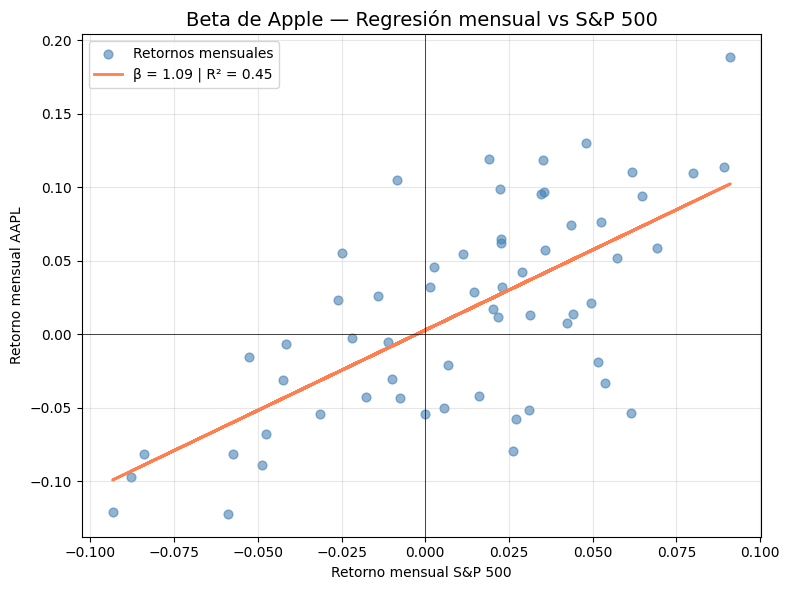

In [4]:
df_aapl_m = retornos_m['AAPL'].join(df_mercado_m['return'], rsuffix='_mercado').dropna().tail(60)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_aapl_m['return_mercado'],
    df_aapl_m['return']
)

x = df_aapl_m['return_mercado']
y_pred = slope * x + intercept

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, df_aapl_m['return'], alpha=0.6, color='steelblue', s=40, label='Retornos mensuales')
ax.plot(x, y_pred, color='coral', linewidth=2, label=f'β = {slope:.2f} | R² = {r_value**2:.2f}')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_title('Beta de Apple — Regresión mensual vs S&P 500', fontsize=14)
ax.set_xlabel('Retorno mensual S&P 500')
ax.set_ylabel('Retorno mensual AAPL')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del beta de Apple

Con un **beta de 1.09**, Apple se mueve prácticamente al ritmo del mercado: amplifica las variaciones del S&P 500 apenas un ~9 %. Es el riesgo sistemático típico de una *megacap* madura y diversificada —ni defensiva (β < 1) ni especialmente agresiva—, coherente además con el enorme peso que la propia acción tiene dentro del índice. El **R² de 0.45** indica que cerca del 45 % de la variación de sus retornos mensuales se explica por el mercado, una co-movimiento alta para una sola acción; el 55 % restante responde a factores propios de la empresa (lanzamientos, márgenes, regulación). Frente a sus pares, Apple comparte el perfil "de mercado" de Microsoft (β 1.07) y Alphabet (β 1.08), mientras que Amazon (β 1.38) y Meta (β 1.29) resultan claramente más volátiles. De cara a la valoración, un β cercano a 1 anticipa un **costo de capital propio muy próximo al retorno esperado del mercado**, que servirá de contraste para la estimación por el modelo de Gordon en los siguientes módulos.

**Resumen de hallazgos** (retornos mensuales, últimos 60 meses vs. S&P 500):

| Empresa | β | R² | Lectura |
|---|:---:|:---:|---|
| **Apple (AAPL)** | **1.09** | **0.45** | Riesgo ~igual al del mercado; lo amplifica ~9 % |
| Microsoft (MSFT) | 1.07 | 0.53 | Perfil casi idéntico a Apple; el más explicado por el mercado |
| Alphabet (GOOGL) | 1.08 | 0.34 | Riesgo de mercado, con más ruido idiosincrático |
| Amazon (AMZN) | 1.38 | 0.45 | Notablemente más agresiva que el mercado |
| Meta (META) | 1.29 | 0.22 | Volátil y muy idiosincrática (R² bajo) |

> **En una frase:** Apple es una acción "de mercado" (β ≈ 1.1) con riesgo sistemático moderado; solo Amazon y Meta destacan como claramente más sensibles al ciclo bursátil.